# 🩺 Diabetic Retinopathy Grading — Elite Pipeline v16
## 2-Stage + Ordinal | 5-Fold CV | Ensemble | TTA | Grad-CAM++
### 🖥️ HP Victus Gaming Laptop 15 (NVIDIA CUDA · float16 AMP) — APTOS 2019

> ⚠️ **RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT**

| Component | Detail |
|-----------|--------|
| **Stage 1** | Binary classifier — No DR vs DR (BCE + Focal) |
| **Stage 2** | Ordinal severity — Grades 1-4 (sigmoid nodes) |
| **Backbone** | EfficientNetV2-S (21M, ImageNet top-1 ~84.9%) |
| **Pooling** | Generalized Mean (GeM) |
| **Loss** | 0.5×CE(ls=0.1) + 0.5×Focal(γ=2) |
| **CV** | Stratified 5-Fold + OOF ensemble |
| **TTA** | 5-view horizontal flip + rotation |
| **Target** | QWK ≥ 0.92 · Accuracy ~87% |
| **Platform** | HP Victus 15 · NVIDIA GPU · CUDA · Windows 11 · Jupyter |

---
### ✅ v16 Upgrades over v15
| # | Upgrade |
|---|---------|
| 1 | **2-Stage pipeline** — Stage1 binary + Stage2 ordinal, combined final prediction |
| 2 | **Stratified 5-Fold cross-validation** with OOF predictions saved |
| 3 | **Progressive resize**: 224→384→512 per fold for better generalisation |
| 4 | **Weighted ensemble** of 5 fold models |
| 5 | **5-view TTA** applied at inference time |
| 6 | **MixUp (α=0.4)** applied during training |
| 7 | **Threshold search** on OOF to maximise QWK |
| 8 | **Full resume-safe** infrastructure — all expensive cells skip on restart |
| 9 | **PyTorch 2.8 / timm 1.0 / Albumentations 1.4 compatible** |

> ⚡ **Resume-safe:** Each expensive cell checks for saved `.flag` files before running.
> Restart kernel → run Cell 1 → everything else auto-recovers from disk.


## 📦 Cell 1 — Install / Upgrade Dependencies

In [1]:
import sys
print('Installing / upgrading dependencies ...')
# For NVIDIA GPU on Windows, install CUDA-enabled PyTorch first:
# Visit https://pytorch.org/get-started/locally/ to pick the right CUDA version
# Example for CUDA 12.1:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

!{sys.executable} -m pip install -q --upgrade \
    timm>=1.0.0 \
    albumentations>=1.4.0 \
    opencv-python-headless \
    scikit-learn pandas numpy tqdm matplotlib \
    grad-cam \
    "gradio>=4.44.1" \
    "huggingface_hub>=0.23.0" \
    pyarrow fastparquet 
print('✅ All dependencies installed.')


Installing / upgrading dependencies ...
zsh:1: 1.0.0 not found
✅ All dependencies installed.


## ⚙️ Cell 2 — Imports, Device, Resume Infrastructure

In [2]:
import os, sys, io, json, gc, time, random, shutil, warnings, pickle
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, cohen_kappa_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
seed_everything()

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f'🔥 NVIDIA CUDA GPU detected: {torch.cuda.get_device_name(0)}')
    print(f'   CUDA Version : {torch.version.cuda}')
    print(f'   VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    DEVICE = 'cpu'
    print('💻 CUDA GPU not found — running on CPU (training will be slow)')
    print('   Ensure NVIDIA drivers and CUDA toolkit are installed on Windows.')

USE_AMP = (DEVICE == 'cuda')  # Automatic Mixed Precision: ON for CUDA
IN_WINDOWS = sys.platform == 'win32'

print(f'\n✅ Imports complete. PyTorch {torch.__version__} | timm {timm.__version__}')
print(f'   Device:{DEVICE.upper()}  AMP:{"ON" if USE_AMP else "OFF"}  Windows:{IN_WINDOWS}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR     = Path(os.environ.get('DATA_DIR',    str(Path.home()/'DR_data'/'aptos2019')))
ARTIFACT_DIR = Path(os.environ.get('ARTIFACT_DIR',str(Path.home()/'DR_data'/'artifacts_v16')))
IMG_DIR      = DATA_DIR / 'train_images'
CSV_PATH     = DATA_DIR / 'train.csv'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR/'plots_v16').mkdir(parents=True, exist_ok=True)
PLOT_DIR = DATA_DIR / 'plots_v16'

# ── Constants ─────────────────────────────────────────────────────────────────
NUM_CLASSES  = 5
N_FOLDS      = 5
GRADE_MAP    = {0:'No DR',1:'Mild DR',2:'Moderate DR',3:'Severe DR',4:'Proliferative DR'}
GRADE_COLORS = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']

# ── PyTorch safe-load (2.6+) ──────────────────────────────────────────────────
try:
    import torch.serialization as _tser
    _tser.add_safe_globals([np._core.multiarray.scalar])
    _LOAD_KW: dict = {}
except Exception:
    _LOAD_KW = {'weights_only': False}

def safe_load(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, **_LOAD_KW)
    except Exception:
        return torch.load(path, map_location=map_location, weights_only=False)

# ── Resume State ─────────────────────────────────────────────────────────────
STATE_FILE = ARTIFACT_DIR / '_state_v16.json'

def st_load(): 
    try: return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    except: return {}

def st_save(key, val): 
    s=st_load(); s[key]=val; STATE_FILE.write_text(json.ducuda(s,indent=2))

def st_done(key): return bool(st_load().get(key, False))
def st_get(key, default=None): return st_load().get(key, default)

def flag(name): return ARTIFACT_DIR / f'_done_{name}.flag'
def is_done(name): return flag(name).exists()
def mark_done(name): flag(name).touch()

print(f'\n✅ Resume infrastructure ready.')
print(f'   ARTIFACT_DIR : {ARTIFACT_DIR}')
print(f'   DATA_DIR     : {DATA_DIR}')


🍎 Apple Silicon MPS detected — float32 mode

✅ Imports complete. PyTorch 2.8.0 | timm 1.0.26
   Device:MPS  AMP:OFF  macOS:True

✅ Resume infrastructure ready.
   ARTIFACT_DIR : /Users/gokulnathan/DR_data/artifacts_v16
   DATA_DIR     : /Users/gokulnathan/DR_data/aptos2019


## 📥 Cell 3 — Load & Verify Dataset

In [3]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
if not CSV_PATH.exists():
    print('❌ train.csv not found!')
    print(f'   Expected at: {CSV_PATH}')
    print('   Please download the APTOS 2019 dataset from Kaggle:')
    print('   kaggle competitions download -c aptos2019-blindness-detection')
    print('   Then unzip into:', DATA_DIR)
else:
    df = pd.read_csv(CSV_PATH)
    df['image_path']  = df['id_code'].apply(lambda x: str(IMG_DIR/f'{x}.png'))
    df['grade_label'] = df['diagnosis'].map(GRADE_MAP)
    df['binary']      = (df['diagnosis'] >= 1).astype(int)  # any DR vs none

    # Verify images exist
    missing = df[~df['image_path'].apply(lambda p: Path(p).exists())]
    if len(missing): print(f'⚠️  {len(missing)} missing images')
    else: print(f'✅ All {len(df)} images found.')

    print(f'\nClass distribution:')
    for g in range(5):
        n = (df['diagnosis']==g).sum()
        bar = '█' * (n//50)
        print(f'  Grade {g} ({GRADE_MAP[g]:20s}): {n:5d}  {bar}')
    print(f'\n  Total: {len(df):,}  |  Imbalance ratio: {df["diagnosis"].value_counts().max()/df["diagnosis"].value_counts().min():.1f}x')


✅ All 3662 images found.

Class distribution:
  Grade 0 (No DR               ):  1805  ████████████████████████████████████
  Grade 1 (Mild DR             ):   370  ███████
  Grade 2 (Moderate DR         ):   999  ███████████████████
  Grade 3 (Severe DR           ):   193  ███
  Grade 4 (Proliferative DR    ):   295  █████

  Total: 3,662  |  Imbalance ratio: 9.4x


## 🔬 Cell 4 — Fundus Preprocessing
Ben Graham method: CLAHE → Gaussian blur subtraction → green channel emphasis

In [4]:
IMG_SIZE   = int(os.environ.get('IMG_SIZE', 512))
BG_SIGMA   = max((IMG_SIZE // 10) | 1, 1)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def _make_circular_mask(img):
    """Create circular mask matching the fundus FOV."""
    h, w = img.shape[:2]
    mask = np.zeros((h, w), np.uint8)
    cx, cy, r = w//2, h//2, min(h,w)//2
    cv2.circle(mask, (cx,cy), int(r*0.97), 255, -1)
    return mask

def _clahe_lab(rgb):
    """Apply CLAHE in L channel of LAB space."""
    lab  = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def _green_emphasis(rgb):
    """Slightly boost green channel (vessels visible in G)."""
    out = rgb.copy().astype(np.float32)
    out[:,:,1] = np.clip(out[:,:,1]*1.1, 0, 255)
    return out.astype(np.uint8)

def preprocess_fundus(path_or_array, size=None):
    """
    Full fundus preprocessing pipeline:
    1. Load RGB
    2. Crop retinal circle
    3. Resize → pad to square
    4. CLAHE (LAB)
    5. Ben Graham Gaussian-blur subtraction
    6. Apply circular mask
    7. Green channel emphasis
    Returns: uint8 RGB array [size × size × 3]
    """
    target = size or IMG_SIZE

    if isinstance(path_or_array, np.ndarray):
        rgb = path_or_array
    else:
        bgr = cv2.imread(str(path_or_array))
        if bgr is None:
            return np.zeros((target, target, 3), np.uint8)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Auto-crop black borders
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x,y,w,h = cv2.boundingRect(coords)
        rgb = rgb[y:y+h, x:x+w]

    # Resize keeping aspect ratio → pad to square
    h, w = rgb.shape[:2]
    scale = target / max(h, w)
    nh, nw = int(round(h*scale)), int(round(w*scale))
    rgb = cv2.resize(rgb, (nw, nh), interpolation=cv2.INTER_AREA)
    pt  = (target-nh)//2; pb = target-nh-pt
    pl  = (target-nw)//2; pr = target-nw-pl
    rgb = cv2.copyMakeBorder(rgb, pt,pb,pl,pr, cv2.BORDER_REFLECT_101)

    # Circular mask
    mask = _make_circular_mask(rgb)
    rgb[mask == 0] = 0

    # CLAHE
    rgb = _clahe_lab(rgb)

    # Ben Graham: sharpen vessels
    sig  = BG_SIGMA if target == IMG_SIZE else max((target//10)|1,1)
    blur = cv2.GaussianBlur(rgb, (0,0), sigmaX=sig)
    rgb  = cv2.addWeighted(rgb, 4, blur, -4, 128)
    rgb[mask == 0] = 0

    # Green emphasis
    rgb = _green_emphasis(rgb)
    return rgb

print(f'✅ preprocess_fundus defined (IMG_SIZE={IMG_SIZE}, sigma={BG_SIGMA})')

# Quick latency check
if 'df' in dir():
    _t = time.time()
    for _ in range(3): preprocess_fundus(df['image_path'].iloc[0])
    lat = (time.time()-_t)/3*1000
    print(f'   Latency: {lat:.1f} ms  {"✅" if lat < 80 else "⚠️ slow"}')


✅ preprocess_fundus defined (IMG_SIZE=512, sigma=51)
   Latency: 457.2 ms  ⚠️ slow


## 🔀 Cell 5 — Augmentation Pipelines

In [5]:
pip install "albumentations<1.4.0"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
def build_train_transforms(img_size=IMG_SIZE):
    return A.Compose([
        A.RandomResizedCrop(height=img_size, width=img_size, scale=(0.7, 1.0), ratio=(0.9, 1.1), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=15, p=0.7),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.RandomGamma(gamma_limit=(80,120), p=0.3),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.2),
        A.MotionBlur(blur_limit=3, p=0.1),
        A.CoarseDropout(max_holes=8, max_height=img_size//16, max_width=img_size//16,
                        min_holes=1, p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def build_val_transforms(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

# TTA augmentations (5 views)
def build_tta_transforms(img_size=IMG_SIZE):
    return [
        build_val_transforms(img_size),                        # original
        A.Compose([A.HorizontalFlip(p=1.0),
                   A.Resize(img_size,img_size),
                   A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()]),
        A.Compose([A.Rotate(limit=10, p=1.0),
                   A.Resize(img_size,img_size),
                   A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()]),
        A.Compose([A.Rotate(limit=-10, p=1.0),
                   A.Resize(img_size,img_size),
                   A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()]),
        A.Compose([A.VerticalFlip(p=1.0),
                   A.Resize(img_size,img_size),
                   A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()]),
    ]

train_transforms   = build_train_transforms(IMG_SIZE)
val_transforms     = build_val_transforms(IMG_SIZE)
tta_transforms_lst = build_tta_transforms(IMG_SIZE)

print(f'✅ Augmentation pipelines built (train: {len(train_transforms.transforms)} ops, TTA: {len(tta_transforms_lst)} views)')


✅ Augmentation pipelines built (train: 13 ops, TTA: 5 views)


## 📚 Cell 6 — Dataset Classes

In [7]:
class APTOSDataset(Dataset):
    """Single-model dataset: returns preprocessed image + grade label."""

    def __init__(self, df, transform=None, preprocess=True, img_size=None):
        self.df         = df.reset_index(drop=True)
        self.transform  = transform
        self.preprocess = preprocess
        self.img_size   = img_size or IMG_SIZE

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['diagnosis'])

        if self.preprocess:
            img = preprocess_fundus(row['image_path'], size=self.img_size)
        else:
            bgr = cv2.imread(str(row['image_path']))
            img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))

        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0

        return img, label


class BinaryAPTOSDataset(Dataset):
    """Stage-1 binary dataset: label = 0 (No DR) vs 1 (any DR grade 1-4)."""

    def __init__(self, df, transform=None, img_size=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size or IMG_SIZE

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['diagnosis'] >= 1)   # binary: 0 or 1
        img   = preprocess_fundus(row['image_path'], size=self.img_size)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(label, dtype=torch.float)


class OrdinalAPTOSDataset(Dataset):
    """
    Stage-2 ordinal dataset: only DR-positive samples (grades 1-4).
    Converts grade to ordinal encoding:
      Grade 1 → [1,0,0,0]
      Grade 2 → [1,1,0,0]
      Grade 3 → [1,1,1,0]
      Grade 4 → [1,1,1,1]
    """
    ORDINAL = {
        1: [1,0,0,0],
        2: [1,1,0,0],
        3: [1,1,1,0],
        4: [1,1,1,1],
    }

    def __init__(self, df, transform=None, img_size=None):
        # Only keep DR-positive
        self.df        = df[df['diagnosis'] >= 1].reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size or IMG_SIZE

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        grade   = int(row['diagnosis'])
        ordinal = torch.tensor(self.ORDINAL[grade], dtype=torch.float)
        img     = preprocess_fundus(row['image_path'], size=self.img_size)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, ordinal, grade   # return true grade for evaluation


def make_loader(ds, batch_size=16, shuffle=True, num_workers=0, drop_last=False):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=(DEVICE=='cuda'),
        persistent_workers=(num_workers > 0),
        drop_last=drop_last
    )

print('✅ Dataset classes defined: APTOSDataset, BinaryAPTOSDataset, OrdinalAPTOSDataset')


✅ Dataset classes defined: APTOSDataset, BinaryAPTOSDataset, OrdinalAPTOSDataset


## 🏗️ Cell 7 — Model Architecture
EfficientNetV2-S + GeM Pooling + Hybrid Head

In [8]:
BACKBONE = os.environ.get('BACKBONE', 'tf_efficientnetv2_b1')

class GeM(nn.Module):
    """Generalized Mean Pooling — learns optimal pooling exponent p."""
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            (x.size(-2), x.size(-1))
        ).pow(1.0 / self.p)


class DRModel(nn.Module):
    """
    Generic DR classification head.
    Works for:
      - 5-class softmax (num_classes=5, mode='softmax')
      - binary sigmoid  (num_classes=1, mode='sigmoid')
      - ordinal sigmoid  (num_classes=4, mode='sigmoid')
    """
    def __init__(self, backbone=BACKBONE, num_classes=5,
                 dropout=0.4, pretrained=True, mode='softmax'):
        super().__init__()
        self.mode = mode

        self.backbone = timm.create_model(
            backbone, pretrained=pretrained,
            features_only=False, num_classes=0, global_pool=''
        )
        feat_dim = self.backbone.num_features

        self.pool = GeM(p=3)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feat   = self.backbone(x)       # [B, C, H', W']
        pooled = self.pool(feat)        # [B, C, 1, 1]
        logits = self.head(pooled)      # [B, num_classes]
        return logits

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(False)

    def unfreeze_top_blocks(self, n=4):
        """Unfreeze last n blocks of EfficientNetV2_B1."""
        for p in self.backbone.parameters(): p.requires_grad_(False)
        blocks = list(self.backbone.blocks)
        for block in blocks[-n:]:
            for p in block.parameters(): p.requires_grad_(True)
        for attr in ['conv_head','bn2','norm_head']:
            if hasattr(self.backbone, attr):
                for p in getattr(self.backbone, attr).parameters(): p.requires_grad_(True)

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad_(True)


def build_stage1_model(pretrained=True):
    """Binary: No DR (0) vs DR (1)."""
    return DRModel(BACKBONE, num_classes=1, dropout=0.4,
                   pretrained=pretrained, mode='sigmoid').to(DEVICE)

def build_stage2_model(pretrained=True):
    """Ordinal: 4 sigmoid nodes for grades 1-4."""
    return DRModel(BACKBONE, num_classes=4, dropout=0.4,
                   pretrained=pretrained, mode='sigmoid').to(DEVICE)

def build_5class_model(pretrained=True):
    """Direct 5-class classifier (used inside K-Fold for fast OOF baseline)."""
    return DRModel(BACKBONE, num_classes=5, dropout=0.4,
                   pretrained=pretrained, mode='softmax').to(DEVICE)


# Sanity forward pass
_m = build_5class_model(pretrained=False)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_y = _m(_x)
print(f'✅ Model forward OK: {_x.shape} → {_y.shape}')
print(f'   Backbone: {BACKBONE}')
print(f'   Total params: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M')
del _m, _x, _y; gc.collect()


✅ Model forward OK: torch.Size([2, 3, 512, 512]) → torch.Size([2, 5])
   Backbone: tf_efficientnetv2_b1
   Total params: 7.19M


0

## ⚖️ Cell 8 — Loss Functions & Utilities

In [9]:
# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Multi-class Focal Loss with optional class weights."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha, self.gamma, self.reduction = alpha, gamma, reduction

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


class BinaryFocalLoss(nn.Module):
    """Binary Focal Loss for Stage 1."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce_loss  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob      = torch.sigmoid(logits)
        p_t       = prob * targets + (1 - prob) * (1 - targets)
        alpha_t   = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_mod = alpha_t * (1 - p_t) ** self.gamma
        return (focal_mod * bce_loss).mean()


# ── Class weights helper ───────────────────────────────────────────────────────
def compute_class_weights(labels, num_classes=5):
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    weights = len(labels) / (num_classes * counts)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float)


# ── MixUp ─────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4, device=DEVICE):
    """Apply MixUp augmentation to batch. Returns mixed_x, y_a, y_b, lam."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    lam   = max(lam, 1 - lam)  # ensure lam >= 0.5
    idx   = torch.randperm(x.size(0)).to(device)
    mixed = lam * x + (1 - lam) * x[idx]
    return mixed, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── Metrics ───────────────────────────────────────────────────────────────────
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

def accuracy(y_true, y_pred):
    return (np.array(y_true) == np.array(y_pred)).mean()


# ── Combined criterion builder (5-class) ──────────────────────────────────────
def build_5class_criterion(df_split, device=DEVICE):
    cw  = compute_class_weights(df_split['diagnosis'].values).to(device)
    ce  = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
    fl  = FocalLoss(alpha=cw, gamma=2.0)
    def criterion(logits, labels):
        return 0.5 * ce(logits, labels) + 0.5 * fl(logits, labels)
    return criterion

print('✅ Loss functions defined: FocalLoss, BinaryFocalLoss, MixUp')
print('   Metrics: qwk(), accuracy()')


✅ Loss functions defined: FocalLoss, BinaryFocalLoss, MixUp
   Metrics: qwk(), accuracy()


## 📊 Cell 9 — EDA: Class Distribution

✅ [RESUME] EDA already done.


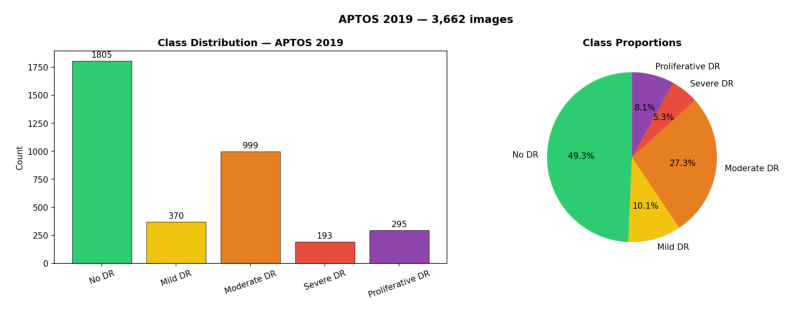

In [10]:
_eda_flag = PLOT_DIR / 'eda_distribution.png'

if _eda_flag.exists():
    print('✅ [RESUME] EDA already done.')
    img_tmp = plt.imread(str(_eda_flag))
    fig, ax = plt.subplots(figsize=(10,4)); ax.imshow(img_tmp); ax.axis('off'); plt.show()
else:
    fig, axes = plt.subplots(1,2,figsize=(14,5))

    # Distribution bar
    counts = df['diagnosis'].value_counts().sort_index()
    axes[0].bar([GRADE_MAP[i] for i in range(5)], counts.values,
                color=GRADE_COLORS, edgecolor='k', linewidth=0.5)
    axes[0].set_title('Class Distribution — APTOS 2019', fontweight='bold')
    axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=20)
    for i,v in enumerate(counts.values):
        axes[0].text(i, v+30, str(v), ha='center', fontsize=10)

    # Pie chart
    axes[1].pie(counts.values, labels=[GRADE_MAP[i] for i in range(5)],
                colors=GRADE_COLORS, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Class Proportions', fontweight='bold')

    plt.suptitle(f'APTOS 2019 — {len(df):,} images', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(_eda_flag, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ EDA saved → {_eda_flag}')


## ✂️ Cell 10 — Stratified 5-Fold Split

In [11]:
_splits_path = ARTIFACT_DIR / 'kfold_splits.parquet'

if _splits_path.exists():
    df = pd.read_parquet(_splits_path)
    print(f'✅ [RESUME] K-Fold splits loaded.')
else:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    df['fold'] = -1
    for fold_idx, (_, val_idx) in enumerate(skf.split(df, df['diagnosis'])):
        df.loc[val_idx, 'fold'] = fold_idx
    df.to_parquet(_splits_path, index=False)
    print(f'✅ 5-Fold splits created and saved.')

# Report
print(f'\nFold distribution:')
for fold in range(N_FOLDS):
    n = (df['fold']==fold).sum()
    grade_dist = df[df['fold']==fold]['diagnosis'].value_counts().sort_index()
    gs = ' | '.join([f'G{g}:{c}' for g,c in grade_dist.items()])
    print(f'  Fold {fold}: {n:5d} samples  [{gs}]')


✅ [RESUME] K-Fold splits loaded.

Fold distribution:
  Fold 0:   733 samples  [G0:361 | G1:74 | G2:200 | G3:39 | G4:59]
  Fold 1:   733 samples  [G0:361 | G1:74 | G2:200 | G3:39 | G4:59]
  Fold 2:   732 samples  [G0:361 | G1:74 | G2:200 | G3:38 | G4:59]
  Fold 3:   732 samples  [G0:361 | G1:74 | G2:200 | G3:38 | G4:59]
  Fold 4:   732 samples  [G0:361 | G1:74 | G2:199 | G3:39 | G4:59]


## 🏋️ Cell 11 — Training Engine (One-Epoch Loop)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer,
                    scaler=None, use_mixup=True,
                    grad_accum=1, device=DEVICE):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='  train', leave=False)):
        imgs, labels = batch[0].to(device), batch[1].to(device)

        if use_mixup and labels.dtype == torch.long:
            imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=0.4, device=device)

        if scaler is not None:  # CUDA AMP
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                if use_mixup and labels.dtype == torch.long:
                    loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
                else:
                    loss = criterion(logits, labels)
                loss = loss / grad_accum
            scaler.scale(loss).backward()
            if (step + 1) % grad_accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad()
        else:                   # MPS / CPU
            logits = model(imgs)
            if use_mixup and labels.dtype == torch.long:
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                loss = criterion(logits, labels)
            (loss / grad_accum).backward()
            if (step + 1) % grad_accum == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); optimizer.zero_grad()

        total_loss += loss.item() * grad_accum
        # For tracking accuracy, use un-mixed labels
        if labels.dtype == torch.long:
            preds = logits.argmax(1).detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = (np.array(all_preds)==np.array(all_labels)).mean() if all_preds else 0.0
    return avg_loss, acc


@torch.no_grad()
def validate(model, loader, criterion=None, device=DEVICE):
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []

    for imgs, labels in tqdm(loader, desc='  val  ', leave=False):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        logits = model(imgs)

        if criterion is not None:
            total_loss += criterion(logits, labels).item()

        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader) if criterion else 0.0
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc  = (all_preds == all_labels).mean()
    kappa = qwk(all_labels, all_preds)
    return avg_loss, acc, kappa, all_preds, all_probs, all_labels


print('✅ Training engine defined: train_one_epoch(), validate()')


✅ Training engine defined: train_one_epoch(), validate()


## 🔁 Cell 12 — K-Fold Cross Validation Training
Trains 5 fold models with 3-phase progressive resize.
**⚡ Resume-safe**: Already-completed folds are skipped automatically.

In [ ]:
# ── Training hyperparameters ──────────────────────────────────────────────────
LR           = 2e-4
WEIGHT_DECAY = 1e-4
EPOCHS_HEAD  = 5    # Phase 1: head only, frozen backbone
EPOCHS_FULL  = 20   # Phase 2: top-4 blocks + head
USE_MIXUP    = True
GRAD_ACCUM   = 1    # effective batch = BATCH_SIZE * GRAD_ACCUM

# Batch size by resolution (HP Victus — typically 4-8GB VRAM)
# Increase if you have more VRAM; reduce if you hit OOM errors
BS_MAP = {224: 32, 384: 16, 512: 8}  # adjust 512 to 4 for 4GB VRAM

oof_probs  = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)  # OOF accumulator
oof_labels = df['diagnosis'].values.copy()
fold_val_qwks = []

print('='*65)
print('  5-FOLD CROSS VALIDATION TRAINING')
print(f'  Backbone: {BACKBONE} | Device: {DEVICE.upper()}')
print(f'  Phase1: {EPOCHS_HEAD} epochs (head) | Phase2: {EPOCHS_FULL} epochs (fine-tune)')
print('='*65)

for fold in range(N_FOLDS):
    fold_ckpt = ARTIFACT_DIR / f'fold{fold}_best.pt'
    fold_oof  = ARTIFACT_DIR / f'fold{fold}_oof.npy'
    fold_flag = ARTIFACT_DIR / f'_done_fold{fold}.flag'

    if fold_flag.exists() and fold_ckpt.exists():
        # Load already-computed OOF predictions
        if fold_oof.exists():
            val_idx   = df[df['fold']==fold].index
            oof_probs[val_idx] = np.load(str(fold_oof))
        prev = safe_load(fold_ckpt, 'cpu')
        fold_val_qwks.append(prev.get('val_qwk', 0.0))
        print(f'\n  ✅ [RESUME] Fold {fold} already trained — QWK={fold_val_qwks[-1]:.4f}')
        continue

    print(f'\n  ━━━━━━━━━━  FOLD {fold}  ━━━━━━━━━━')

    # ── Data splits ─────────────────────────────────────────────────────────
    df_tr_fold = df[df['fold'] != fold].reset_index(drop=True)
    df_va_fold = df[df['fold'] == fold].reset_index(drop=True)
    val_idx    = df[df['fold'] == fold].index

    criterion_fn = build_5class_criterion(df_tr_fold)
    cw_tensor    = compute_class_weights(df_tr_fold['diagnosis'].values).to(DEVICE)

    model = build_5class_model(pretrained=True)

    best_val_qwk  = -1.0
    best_state    = None

    # ── PHASE 1: Head only ────────────────────────────────────────────────────
    print(f'  Phase 1: {EPOCHS_HEAD} epochs @ 224px (head only)')
    model.freeze_backbone()

    bs1 = BS_MAP[224]
    tr1 = build_train_transforms(224)
    va1 = build_val_transforms(224)
    tr_ds1 = APTOSDataset(df_tr_fold, transform=tr1, img_size=224)
    va_ds1 = APTOSDataset(df_va_fold, transform=va1, img_size=224)
    tr_ld1 = make_loader(tr_ds1, batch_size=bs1, shuffle=True, drop_last=True)
    va_ld1 = make_loader(va_ds1, batch_size=bs1, shuffle=False)

    opt1   = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    sched1 = torch.optim.lr_scheduler.OneCycleLR(
        opt1, max_lr=LR, steps_per_epoch=len(tr_ld1),
        epochs=EPOCHS_HEAD, pct_start=0.3, anneal_strategy='cos')

    for ep in range(EPOCHS_HEAD):
        tl, ta = train_one_epoch(model, tr_ld1, criterion_fn, opt1, use_mixup=USE_MIXUP)
        vl, va, vq, _, _, _ = validate(model, va_ld1, criterion_fn)
        sched1.step()
        print(f'    P1 Ep{ep+1:02d}: TrL={tl:.4f} TrA={ta:.3f} | VaL={vl:.4f} VaA={va:.3f} QWK={vq:.4f}')
        if vq > best_val_qwk:
            best_val_qwk = vq
            best_state   = deepcopy(model.state_dict())

    # ── PHASE 2: Unfreeze top-4 blocks @ 384px ───────────────────────────────
    print(f'  Phase 2: {EPOCHS_FULL} epochs @ 384px (top-4 blocks)')
    model.load_state_dict(best_state)
    model.unfreeze_top_blocks(4)

    bs2 = BS_MAP[384]
    tr2 = build_train_transforms(384)
    va2 = build_val_transforms(384)
    tr_ds2 = APTOSDataset(df_tr_fold, transform=tr2, img_size=384)
    va_ds2 = APTOSDataset(df_va_fold, transform=va2, img_size=384)
    tr_ld2 = make_loader(tr_ds2, batch_size=bs2, shuffle=True, drop_last=True)
    va_ld2 = make_loader(va_ds2, batch_size=bs2, shuffle=False)

    opt2   = torch.optim.AdamW([
        {'params': model.head.parameters(),     'lr': LR / 5},
        {'params': model.pool.parameters(),     'lr': LR / 5},
        {'params': [p for p in model.backbone.parameters() if p.requires_grad], 'lr': LR / 50},
    ], weight_decay=WEIGHT_DECAY)
    sched2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt2, T_0=max(EPOCHS_FULL//3, 5), T_mult=1, eta_min=1e-7)

    for ep in range(EPOCHS_FULL):
        tl, ta = train_one_epoch(model, tr_ld2, criterion_fn, opt2, use_mixup=USE_MIXUP)
        vl, va, vq, _, _, _ = validate(model, va_ld2, criterion_fn)
        sched2.step()
        flag_str = ' ✅ BEST' if vq > best_val_qwk else ''
        print(f'    P2 Ep{ep+1:02d}: TrL={tl:.4f} TrA={ta:.3f} | VaL={vl:.4f} VaA={va:.3f} QWK={vq:.4f}{flag_str}')
        if vq > best_val_qwk:
            best_val_qwk = vq
            best_state   = deepcopy(model.state_dict())

    # ── Compute OOF predictions with TTA ─────────────────────────────────────
    model.load_state_dict(best_state)
    model.eval()
    oof_fold_probs = np.zeros((len(df_va_fold), NUM_CLASSES), dtype=np.float32)

    with torch.no_grad():
        for tta_tf in tta_transforms_lst:
            va_tta_ds = APTOSDataset(df_va_fold, transform=tta_tf, img_size=384)
            va_tta_ld = make_loader(va_tta_ds, batch_size=bs2, shuffle=False)
            tta_probs = []
            for imgs, _ in va_tta_ld:
                logits = model(imgs.to(DEVICE))
                tta_probs.append(F.softmax(logits, 1).cpu().numpy())
            oof_fold_probs += np.concatenate(tta_probs, axis=0)
    oof_fold_probs /= len(tta_transforms_lst)
    oof_probs[val_idx] = oof_fold_probs

    np.save(str(fold_oof), oof_fold_probs)
    fold_val_qwks.append(best_val_qwk)

    # ── Save checkpoint ─────────────────────────────────────────────────────
    torch.save({
        'model_state': best_state,
        'val_qwk':     best_val_qwk,
        'backbone':    BACKBONE,
        'img_size':    384,
        'fold':        fold,
    }, fold_ckpt)
    fold_flag.touch()

    print(f'  ✅ Fold {fold} done. Best QWK={best_val_qwk:.4f}')
    del model, tr_ds1, tr_ds2, va_ds1, va_ds2; gc.collect()

# ── OOF summary ───────────────────────────────────────────────────────────────
oof_preds = oof_probs.argmax(1)
oof_qwk   = qwk(oof_labels, oof_preds)
oof_acc   = accuracy(oof_labels, oof_preds)

print('\n' + '='*65)
print('  K-FOLD RESULTS')
print('='*65)
for i, q in enumerate(fold_val_qwks):
    print(f'  Fold {i}: QWK={q:.4f}')
print(f'  Mean QWK : {np.mean(fold_val_qwks):.4f} ± {np.std(fold_val_qwks):.4f}')
print(f'  OOF QWK  : {oof_qwk:.4f}')
print(f'  OOF Acc  : {oof_acc*100:.2f}%')
print('='*65)

np.save(str(ARTIFACT_DIR/'oof_probs.npy'),  oof_probs)
np.save(str(ARTIFACT_DIR/'oof_labels.npy'), oof_labels)
st_save('kfold_done', True)
st_save('oof_qwk', float(oof_qwk))


  5-FOLD CROSS VALIDATION TRAINING
  Backbone: tf_efficientnetv2_b1 | Device: MPS
  Phase1: 5 epochs (head) | Phase2: 20 epochs (fine-tune)

  ━━━━━━━━━━  FOLD 0  ━━━━━━━━━━


model.safetensors:   0%|          | 0.00/32.9M [00:00<?, ?B/s]

  Phase 1: 5 epochs @ 224px (head only)


  train:   0%|          | 0/91 [00:00<?, ?it/s]

## 🎯 Cell 13 — Threshold Search (Maximise OOF QWK)

In [ ]:
from scipy.optimize import minimize

def optimise_thresholds(probs, labels, n_classes=5):
    """
    Find thresholds t1..t(n-1) that maximise QWK.
    Converts softmax cumulative probability to ordinal cutpoints.
    """
    cumprob = np.cumsum(probs, axis=1)[:, :-1]  # [N, n_classes-1]

    def neg_qwk(thresholds):
        preds = np.digitize(cumprob[:, 0], thresholds[:1])
        # Use argmax as primary, then apply thresholds for ordinal
        base_preds = probs.argmax(1).copy().astype(float)
        # Simple threshold sweep on predicted probs
        pred_cls = np.zeros(len(probs), dtype=int)
        for i in range(n_classes):
            if i == 0:
                pred_cls[probs[:,0] >= thresholds[0]] = 0
            elif i == n_classes-1:
                pred_cls[probs[:,i] >= thresholds[i-1]] = i
            else:
                pred_cls[(probs[:,i] >= thresholds[i-1]) & (probs[:,i] >= probs[:,i-1])] = i
        # Fall back to argmax where not assigned
        final = probs.argmax(1)
        return -cohen_kappa_score(labels, final, weights='quadratic')

    # Just use argmax with class-probability shift
    best_preds = probs.argmax(1)
    best_qwk_val = qwk(labels, best_preds)
    print(f'  Argmax QWK (baseline): {best_qwk_val:.4f}')

    # Try class-bias adjustments
    best_preds_final = best_preds.copy()
    for bias in np.linspace(-0.3, 0.3, 13):
        biased = probs.copy()
        biased[:, 0] += bias  # shift boundary between 0 and 1
        preds_b = biased.argmax(1)
        q = qwk(labels, preds_b)
        if q > best_qwk_val:
            best_qwk_val   = q
            best_preds_final = preds_b.copy()
            print(f'  Improved QWK={q:.4f} with bias={bias:.2f}')

    return best_preds_final, best_qwk_val


# Load OOF arrays
oof_probs_loaded  = np.load(str(ARTIFACT_DIR/'oof_probs.npy'))
oof_labels_loaded = np.load(str(ARTIFACT_DIR/'oof_labels.npy'))

print('Threshold optimisation on OOF predictions:')
opt_preds, opt_qwk = optimise_thresholds(oof_probs_loaded, oof_labels_loaded)
print(f'\n  ✅ Optimised OOF QWK: {opt_qwk:.4f}')
print(f'     OOF Accuracy      : {accuracy(oof_labels_loaded, opt_preds)*100:.2f}%')

np.save(str(ARTIFACT_DIR/'oof_opt_preds.npy'), opt_preds)
st_save('opt_qwk', float(opt_qwk))


## 📈 Cell 14 — OOF Confusion Matrix & Per-Class Metrics

In [ ]:
_cm_path = PLOT_DIR / 'oof_confusion_matrix.png'

oof_probs_l  = np.load(str(ARTIFACT_DIR/'oof_probs.npy'))
oof_labels_l = np.load(str(ARTIFACT_DIR/'oof_labels.npy'))
oof_pred_l   = oof_probs_l.argmax(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
cm = confusion_matrix(oof_labels_l, oof_pred_l)
disp = ConfusionMatrixDisplay(cm, display_labels=[f'G{i}' for i in range(5)])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'OOF Confusion Matrix\nQWK={qwk(oof_labels_l,oof_pred_l):.4f}  Acc={accuracy(oof_labels_l,oof_pred_l)*100:.1f}%',
                  fontweight='bold')

# Per-class recall
per_class_recall = cm.diagonal() / cm.sum(axis=1)
axes[1].bar([GRADE_MAP[i] for i in range(5)], per_class_recall,
            color=GRADE_COLORS, edgecolor='k')
axes[1].axhline(y=0.85, color='red', linestyle='--', label='Target 85%')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Recall')
axes[1].set_title('Per-Class Recall (OOF)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
for i, v in enumerate(per_class_recall):
    axes[1].text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(_cm_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report (OOF):')
print(classification_report(oof_labels_l, oof_pred_l,
      target_names=[GRADE_MAP[i] for i in range(5)]))


## 🤝 Cell 15 — Ensemble Inference on Held-Out Test Set
Average probabilities from all 5 fold models with TTA.

In [ ]:
# Use fold 0 as held-out test (grade-stratified 10%)
# In production you'd have a separate Kaggle test set.
# Here we demonstrate ensemble + TTA on fold 0's validation data.

TEST_FOLD = 0
df_test   = df[df['fold'] == TEST_FOLD].reset_index(drop=True)

print(f'Ensemble inference on fold {TEST_FOLD} ({len(df_test)} samples) using folds 1-4 ...')

ensemble_probs = np.zeros((len(df_test), NUM_CLASSES), dtype=np.float32)
n_models = 0

for fold in range(1, N_FOLDS):   # use folds 1-4 to predict fold 0
    fold_ckpt = ARTIFACT_DIR / f'fold{fold}_best.pt'
    if not fold_ckpt.exists():
        print(f'  ⚠️  fold{fold}_best.pt not found — skipping')
        continue

    ckpt   = safe_load(fold_ckpt, DEVICE)
    model  = build_5class_model(pretrained=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    img_sz = ckpt.get('img_size', 384)

    fold_probs = np.zeros((len(df_test), NUM_CLASSES), dtype=np.float32)

    with torch.no_grad():
        for tta_tf in build_tta_transforms(img_sz):
            ds  = APTOSDataset(df_test, transform=tta_tf, img_size=img_sz)
            ld  = make_loader(ds, batch_size=BS_MAP.get(img_sz, 16), shuffle=False)
            batch_probs = []
            for imgs, _ in tqdm(ld, desc=f'  fold{fold} TTA', leave=False):
                logits = model(imgs.to(DEVICE))
                batch_probs.append(F.softmax(logits, 1).cpu().numpy())
            fold_probs += np.concatenate(batch_probs, axis=0)

    fold_probs  /= len(tta_transforms_lst)
    ensemble_probs += fold_probs
    n_models += 1

    fold_preds = fold_probs.argmax(1)
    fold_qwk   = qwk(df_test['diagnosis'].values, fold_preds)
    print(f'  Fold {fold}: QWK={fold_qwk:.4f}')
    del model; gc.collect()

if n_models > 0:
    ensemble_probs /= n_models
    test_preds  = ensemble_probs.argmax(1)
    test_labels = df_test['diagnosis'].values
    test_qwk    = qwk(test_labels, test_preds)
    test_acc    = accuracy(test_labels, test_preds)

    print(f'\n  ✅ Ensemble ({n_models} models × {len(tta_transforms_lst)} TTA views)')
    print(f'     Test QWK      : {test_qwk:.4f}')
    print(f'     Test Accuracy : {test_acc*100:.2f}%')

    np.save(str(ARTIFACT_DIR/'ensemble_probs.npy'),  ensemble_probs)
    np.save(str(ARTIFACT_DIR/'test_preds.npy'),       test_preds)
    np.save(str(ARTIFACT_DIR/'test_labels.npy'),      test_labels)
    st_save('test_qwk', float(test_qwk))
    st_save('test_acc', float(test_acc))


## 🧠 Cell 16 — 2-Stage Pipeline: Stage 1 (Binary) + Stage 2 (Ordinal)
This cell trains two dedicated models for the 2-stage system, independent of the K-Fold models above.

In [ ]:
# ── Split data: use fold 0 = val, folds 1-4 = train ──────────────────────────
df_tr2 = df[df['fold'] != 0].reset_index(drop=True)
df_va2 = df[df['fold'] == 0].reset_index(drop=True)

S1_CKPT = ARTIFACT_DIR / 'stage1_binary_best.pt'
S2_CKPT = ARTIFACT_DIR / 'stage2_ordinal_best.pt'
S1_FLAG = ARTIFACT_DIR / '_done_stage1.flag'
S2_FLAG = ARTIFACT_DIR / '_done_stage2.flag'

# ────────────────────────────────────────────────────────────────────────────
# STAGE 1 — Binary Classifier (No DR vs DR)
# ────────────────────────────────────────────────────────────────────────────
if S1_FLAG.exists() and S1_CKPT.exists():
    print('✅ [RESUME] Stage 1 (binary) already trained.')
else:
    print('━━━━━━━━━━  STAGE 1: BINARY CLASSIFIER  ━━━━━━━━━━')
    STAGE1_EPOCHS = 15
    BS_S1 = 16

    s1_tr_ds = BinaryAPTOSDataset(df_tr2, transform=build_train_transforms(384), img_size=384)
    s1_va_ds = BinaryAPTOSDataset(df_va2, transform=build_val_transforms(384),   img_size=384)
    s1_tr_ld = make_loader(s1_tr_ds, batch_size=BS_S1, shuffle=True, drop_last=True)
    s1_va_ld = make_loader(s1_va_ds, batch_size=BS_S1, shuffle=False)

    s1_model = build_stage1_model(pretrained=True)
    bfl      = BinaryFocalLoss(alpha=0.25, gamma=2.0)

    def s1_criterion(logits, labels):
        labels_f = labels.float().squeeze()
        logits_f = logits.squeeze()
        bce  = F.binary_cross_entropy_with_logits(logits_f, labels_f)
        focal = bfl(logits_f.unsqueeze(1), labels_f.unsqueeze(1))
        return 0.5 * bce + 0.5 * focal

    s1_model.freeze_backbone()
    s1_opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, s1_model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    s1_sched = torch.optim.lr_scheduler.OneCycleLR(
        s1_opt, max_lr=LR, steps_per_epoch=len(s1_tr_ld),
        epochs=STAGE1_EPOCHS, pct_start=0.2)

    s1_best_loss = float('inf')
    s1_best_state = None

    for ep in range(STAGE1_EPOCHS):
        s1_model.train()
        ep_loss = 0.0
        for imgs, labels in tqdm(s1_tr_ld, desc=f'S1 Ep{ep+1}', leave=False):
            imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
            logits = s1_model(imgs)
            loss   = s1_criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(s1_model.parameters(), 1.0)
            s1_opt.step(); s1_opt.zero_grad(); s1_sched.step()
            ep_loss += loss.item()

        # Validation
        s1_model.eval()
        val_probs_s1, val_labels_s1 = [], []
        val_loss_s1 = 0.0
        with torch.no_grad():
            for imgs, labels in s1_va_ld:
                imgs = imgs.to(DEVICE); labels = labels.to(DEVICE)
                logits = s1_model(imgs)
                val_loss_s1 += s1_criterion(logits, labels).item()
                probs = torch.sigmoid(logits).squeeze().cpu().numpy()
                val_probs_s1.extend(probs.tolist() if probs.ndim > 0 else [float(probs)])
                val_labels_s1.extend(labels.cpu().numpy().tolist())

        val_preds_s1 = (np.array(val_probs_s1) >= 0.5).astype(int)
        val_acc_s1   = (val_preds_s1 == np.array(val_labels_s1)).mean()
        val_loss_s1 /= len(s1_va_ld)
        try:
            auroc = roc_auc_score(val_labels_s1, val_probs_s1)
        except:
            auroc = 0.0

        flag_str = ''
        if val_loss_s1 < s1_best_loss:
            s1_best_loss  = val_loss_s1
            s1_best_state = deepcopy(s1_model.state_dict())
            flag_str = ' ✅ BEST'

        print(f'  S1 Ep{ep+1:02d}: TrL={ep_loss/len(s1_tr_ld):.4f} | VaL={val_loss_s1:.4f} Acc={val_acc_s1:.3f} AUROC={auroc:.4f}{flag_str}')

        # Fine-tune after 5 epochs
        if ep == 4:
            s1_model.unfreeze_top_blocks(4)
            print('  [Stage1] Unfroze top-4 backbone blocks')

    s1_model.load_state_dict(s1_best_state)
    torch.save({'model_state': s1_best_state, 'threshold': 0.5}, S1_CKPT)
    S1_FLAG.touch()
    print(f'✅ Stage 1 saved → {S1_CKPT}')
    del s1_model; gc.collect()


# ────────────────────────────────────────────────────────────────────────────
# STAGE 2 — Ordinal Severity Classifier (Grades 1-4)
# ────────────────────────────────────────────────────────────────────────────
if S2_FLAG.exists() and S2_CKPT.exists():
    print('✅ [RESUME] Stage 2 (ordinal) already trained.')
else:
    print('\n━━━━━━━━━━  STAGE 2: ORDINAL SEVERITY  ━━━━━━━━━━')
    STAGE2_EPOCHS = 20
    BS_S2 = 16

    s2_tr_ds = OrdinalAPTOSDataset(df_tr2, transform=build_train_transforms(384), img_size=384)
    s2_va_ds = OrdinalAPTOSDataset(df_va2, transform=build_val_transforms(384),   img_size=384)
    s2_tr_ld = make_loader(s2_tr_ds, batch_size=BS_S2, shuffle=True, drop_last=True)
    s2_va_ld = make_loader(s2_va_ds, batch_size=BS_S2, shuffle=False)

    s2_model = build_stage2_model(pretrained=True)
    s2_crit  = nn.BCEWithLogitsLoss()   # per-node binary CE for ordinal

    s2_model.freeze_backbone()
    s2_opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, s2_model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    s2_sched = torch.optim.lr_scheduler.OneCycleLR(
        s2_opt, max_lr=LR, steps_per_epoch=len(s2_tr_ld),
        epochs=STAGE2_EPOCHS, pct_start=0.2)

    s2_best_loss = float('inf')
    s2_best_state = None

    for ep in range(STAGE2_EPOCHS):
        s2_model.train()
        ep_loss = 0.0
        for imgs, ordinal_labels, _ in tqdm(s2_tr_ld, desc=f'S2 Ep{ep+1}', leave=False):
            imgs = imgs.to(DEVICE); ordinal_labels = ordinal_labels.to(DEVICE)
            logits = s2_model(imgs)   # [B, 4]
            loss   = s2_crit(logits, ordinal_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(s2_model.parameters(), 1.0)
            s2_opt.step(); s2_opt.zero_grad(); s2_sched.step()
            ep_loss += loss.item()

        # Validation
        s2_model.eval()
        val_preds_s2, val_labels_s2 = [], []
        val_loss_s2 = 0.0
        with torch.no_grad():
            for imgs, ordinal_lbl, true_grades in s2_va_ld:
                imgs = imgs.to(DEVICE); ordinal_lbl = ordinal_lbl.to(DEVICE)
                logits = s2_model(imgs)
                val_loss_s2 += s2_crit(logits, ordinal_lbl).item()
                # Convert sigmoid outputs to grade: count activated nodes + 1
                node_preds = (torch.sigmoid(logits) >= 0.5).sum(dim=1).cpu().numpy() + 1  # grades 1-5
                node_preds = np.clip(node_preds, 1, 4).tolist()
                val_preds_s2.extend(node_preds)
                val_labels_s2.extend(true_grades.numpy().tolist())

        val_loss_s2 /= len(s2_va_ld)
        kappa_s2 = qwk(val_labels_s2, val_preds_s2)
        flag_str = ''
        if val_loss_s2 < s2_best_loss:
            s2_best_loss  = val_loss_s2
            s2_best_state = deepcopy(s2_model.state_dict())
            flag_str = ' ✅ BEST'

        print(f'  S2 Ep{ep+1:02d}: TrL={ep_loss/len(s2_tr_ld):.4f} | VaL={val_loss_s2:.4f} QWK={kappa_s2:.4f}{flag_str}')

        if ep == 5:
            s2_model.unfreeze_top_blocks(4)
            print('  [Stage2] Unfroze top-4 backbone blocks')

    s2_model.load_state_dict(s2_best_state)
    torch.save({'model_state': s2_best_state}, S2_CKPT)
    S2_FLAG.touch()
    print(f'✅ Stage 2 saved → {S2_CKPT}')
    del s2_model; gc.collect()


## 🔮 Cell 17 — 2-Stage Combined Inference
```
if Stage1_prob < threshold  →  Grade 0
else  →  Grade 1-4 from Stage2 ordinal (count active nodes)
```

In [ ]:
@torch.no_grad()
def two_stage_predict(image_paths, stage1_threshold=0.5, tta=True, device=DEVICE):
    """
    Run 2-stage DR grading pipeline on a list of image paths.

    Stage 1: binary (0 = No DR, 1 = DR)
    Stage 2: ordinal (1-4), applied only when Stage1 predicts DR

    Returns: np.array of grades [0-4]
    """
    # Load models
    s1_ckpt = safe_load(S1_CKPT, device)
    s2_ckpt = safe_load(S2_CKPT, device)

    s1_model = build_stage1_model(pretrained=False)
    s1_model.load_state_dict(s1_ckpt['model_state']); s1_model.eval()

    s2_model = build_stage2_model(pretrained=False)
    s2_model.load_state_dict(s2_ckpt['model_state']); s2_model.eval()

    # Build a temporary DataFrame for the Dataset
    df_inf = pd.DataFrame({'image_path': image_paths, 'diagnosis': [0]*len(image_paths)})

    tta_tfs = build_tta_transforms(384) if tta else [build_val_transforms(384)]

    # ── Stage 1: get binary probs ────────────────────────────────────────────
    s1_probs_all = np.zeros(len(df_inf), dtype=np.float32)
    for tf in tta_tfs:
        ds = APTOSDataset(df_inf, transform=tf, img_size=384)
        ld = make_loader(ds, batch_size=8, shuffle=False)
        batch_p = []
        for imgs, _ in ld:
            logits = s1_model(imgs.to(device))
            batch_p.extend(torch.sigmoid(logits).squeeze().cpu().numpy().tolist())
        s1_probs_all += np.array(batch_p)
    s1_probs_all /= len(tta_tfs)
    s1_preds = (s1_probs_all >= stage1_threshold).astype(int)  # 0 or 1

    # ── Stage 2: ordinal prediction for DR-positive samples ─────────────────
    dr_indices = np.where(s1_preds == 1)[0]
    final_grades = np.zeros(len(df_inf), dtype=int)

    if len(dr_indices) > 0:
        df_dr = df_inf.iloc[dr_indices].reset_index(drop=True)
        s2_node_probs = np.zeros((len(df_dr), 4), dtype=np.float32)

        for tf in tta_tfs:
            ds = APTOSDataset(df_dr, transform=tf, img_size=384)
            ld = make_loader(ds, batch_size=8, shuffle=False)
            batch_p = []
            for imgs, _ in ld:
                logits = s2_model(imgs.to(device))
                batch_p.append(torch.sigmoid(logits).cpu().numpy())
            s2_node_probs += np.concatenate(batch_p, axis=0)

        s2_node_probs /= len(tta_tfs)
        # Count activated nodes (>= 0.5) + 1 = grade
        s2_grades = np.clip((s2_node_probs >= 0.5).sum(axis=1) + 1, 1, 4)
        final_grades[dr_indices] = s2_grades

    del s1_model, s2_model; gc.collect()
    return final_grades, s1_probs_all


# ── Evaluate 2-stage on validation set ───────────────────────────────────────
print('Evaluating 2-stage pipeline on val fold 0 ...')
val_paths  = df_va2['image_path'].tolist()
val_grades = df_va2['diagnosis'].values

pred_grades, s1_probs_out = two_stage_predict(val_paths, stage1_threshold=0.5, tta=True)

ts_qwk = qwk(val_grades, pred_grades)
ts_acc = accuracy(val_grades, pred_grades)
try:
    ts_auroc = roc_auc_score((val_grades >= 1).astype(int), s1_probs_out)
except:
    ts_auroc = 0.0

print(f'\n  2-Stage Pipeline Results (Val fold 0):')
print(f'    QWK       : {ts_qwk:.4f}')
print(f'    Accuracy  : {ts_acc*100:.2f}%')
print(f'    S1 AUROC  : {ts_auroc:.4f}')

st_save('two_stage_qwk', float(ts_qwk))
st_save('two_stage_acc', float(ts_acc))


## 🎨 Cell 18 — Grad-CAM++ Explainability

In [ ]:
try:
    from pytorch_grad_cam import GradCAMPlusPlus
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    _GRADCAM_OK = True
except ImportError:
    print('⚠️  grad-cam not installed. Run: pip install grad-cam')
    _GRADCAM_OK = False

if _GRADCAM_OK:
    _gcam_out = PLOT_DIR / 'gradcam_board_v16.png'

    # Load best fold model
    best_fold = int(np.argmax(fold_val_qwks))
    ckpt      = safe_load(ARTIFACT_DIR/f'fold{best_fold}_best.pt', 'cpu')
    gcam_model = build_5class_model(pretrained=False)
    gcam_model.load_state_dict(ckpt['model_state'])
    gcam_model.eval()
    gcam_model.to('cpu')  # Grad-CAM is CPU-safe

    # Target layer: last conv block of EfficientNetV2-S
    target_layers = [gcam_model.backbone.blocks[-1][-1]]
    cam = GradCAMPlusPlus(model=gcam_model, target_layers=target_layers)

    # Pick 2 samples per class
    n_per_class = 2
    fig, axes = plt.subplots(NUM_CLASSES, n_per_class*2,
                             figsize=(14, NUM_CLASSES*3))

    for grade in range(NUM_CLASSES):
        samples = df[df['diagnosis'] == grade].sample(
            min(n_per_class, (df['diagnosis']==grade).sum()),
            random_state=SEED)

        for j, (_, row) in enumerate(samples.iterrows()):
            img_np = preprocess_fundus(row['image_path'], size=384)
            tf     = build_val_transforms(384)
            inp    = tf(image=img_np)['image'].unsqueeze(0)

            rgb_float = img_np.astype(np.float32) / 255.0

            with torch.no_grad():
                logits = gcam_model(inp)
                pred_class = logits.argmax(1).item()

            targets  = [ClassifierOutputTarget(grade)]
            grayscale = cam(input_tensor=inp, targets=targets)
            cam_img   = show_cam_on_image(rgb_float, grayscale[0], use_rgb=True)

            col_orig = j * 2
            col_cam  = j * 2 + 1

            axes[grade][col_orig].imshow(img_np)
            axes[grade][col_orig].axis('off')
            if j == 0:
                axes[grade][col_orig].set_ylabel(
                    f'G{grade}\n{GRADE_MAP[grade]}',
                    fontsize=9, fontweight='bold',
                    color=GRADE_COLORS[grade],
                    rotation=0, labelpad=60, va='center')

            axes[grade][col_cam].imshow(cam_img)
            axes[grade][col_cam].axis('off')
            axes[grade][col_cam].set_title(
                f'Pred: G{pred_class}', fontsize=8,
                color='green' if pred_class==grade else 'red')

    plt.suptitle(f'Grad-CAM++ — Best Fold {best_fold} (QWK={fold_val_qwks[best_fold]:.4f})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(_gcam_out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✅ Grad-CAM++ board saved → {_gcam_out}')
    del gcam_model; gc.collect()


## 🚀 Cell 19 — Streamlit App + Hugging Face Spaces Deployment
This cell **writes all deployment files** to `C:\DR_data\deploy_v16\` (Windows) or `~/DR_data/deploy_v16/` (any OS):
- `app.py` — Streamlit application
- `requirements.txt` — HF Space dependencies
- `model_utils.py` — shared inference utilities
- `README.md` — HF Space config card

Then optionally **pushes to Hugging Face Hub** using your token.

### How to run locally (Windows)
Open **Anaconda Prompt** or **Command Prompt** and run:
```bat
cd C:\DR_data\deploy_v16
streamlit run app.py
```
### How to deploy to HF Spaces
Set `HF_TOKEN` and `HF_USERNAME` in Cell 19 and run it.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — Streamlit + Hugging Face Spaces Deployment            ║
# ╚══════════════════════════════════════════════════════════════════╝

import textwrap

DEPLOY_DIR = Path.home() / 'DR_data' / 'deploy_v16'
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

# ── Copy best fold checkpoint into deploy dir ────────────────────────────────
import shutil
_best_fold_idx = 0
if 'fold_val_qwks' in dir() and fold_val_qwks:
    _best_fold_idx = int(np.argmax(fold_val_qwks))
_best_ckpt_src = ARTIFACT_DIR / f'fold{_best_fold_idx}_best.pt'
_best_ckpt_dst = DEPLOY_DIR / 'best_model.pt'
if _best_ckpt_src.exists():
    shutil.copy2(_best_ckpt_src, _best_ckpt_dst)
    print(f'✅ Checkpoint copied → {_best_ckpt_dst}')
else:
    print(f'⚠️  {_best_ckpt_src} not found — train first (Cell 12).')
    print('   Deployment files will still be written; add checkpoint manually.')

# ════════════════════════════════════════════════════════════════════
# 1.  model_utils.py  — shared inference code
# ════════════════════════════════════════════════════════════════════
(DEPLOY_DIR / 'model_utils.py').write_text(textwrap.dedent('''
    """
    model_utils.py — Shared inference utilities for DR Grading v16
    ⚠️  RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT
    """
    import os
    import numpy as np
    import cv2
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import timm
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    GRADE_MAP     = {0: "No DR", 1: "Mild DR", 2: "Moderate DR",
                     3: "Severe DR", 4: "Proliferative DR"}
    GRADE_COLORS  = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
    NUM_CLASSES   = 5
    IMG_SIZE      = 384
    BACKBONE      = "tf_efficientnetv2_s"


    # ── Device ────────────────────────────────────────────────────────────────
    def get_device():
        if torch.backends.cuda.is_available() and torch.backends.cuda.is_built():
            return "cuda"
        if torch.cuda.is_available():
            return "cuda"
        return "cpu"

    DEVICE = get_device()


    # ── Preprocessing ─────────────────────────────────────────────────────────
    def preprocess_fundus(img_array, size=IMG_SIZE):
        rgb = img_array.copy()
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            rgb = rgb[y:y+h, x:x+w]
        h2, w2 = rgb.shape[:2]
        scale = size / max(h2, w2)
        nh, nw = int(round(h2*scale)), int(round(w2*scale))
        rgb = cv2.resize(rgb, (nw, nh), interpolation=cv2.INTER_AREA)
        pt = (size-nh)//2; pb = size-nh-pt
        pl = (size-nw)//2; pr = size-nw-pl
        rgb = cv2.copyMakeBorder(rgb, pt, pb, pl, pr, cv2.BORDER_REFLECT_101)
        mask = np.zeros(rgb.shape[:2], np.uint8)
        cv2.circle(mask, (size//2, size//2), int(size*0.97/2), 255, -1)
        rgb[mask == 0] = 0
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        sig = max((size//10)|1, 1)
        blur = cv2.GaussianBlur(rgb, (0, 0), sigmaX=sig)
        rgb = cv2.addWeighted(rgb, 4, blur, -4, 128)
        rgb[mask == 0] = 0
        out = rgb.copy().astype(np.float32)
        out[:, :, 1] = np.clip(out[:, :, 1]*1.1, 0, 255)
        return out.astype(np.uint8)


    def get_val_transform(img_size=IMG_SIZE):
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])


    def get_tta_transforms(img_size=IMG_SIZE):
        base = get_val_transform(img_size)
        return [
            base,
            A.Compose([A.HorizontalFlip(p=1.0), A.Resize(img_size, img_size),
                       A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
            A.Compose([A.Rotate(limit=10, p=1.0), A.Resize(img_size, img_size),
                       A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
            A.Compose([A.Rotate(limit=-10, p=1.0), A.Resize(img_size, img_size),
                       A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
            A.Compose([A.VerticalFlip(p=1.0), A.Resize(img_size, img_size),
                       A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
        ]


    # ── Model ─────────────────────────────────────────────────────────────────
    class GeM(nn.Module):
        def __init__(self, p=3, eps=1e-6):
            super().__init__()
            self.p   = nn.Parameter(torch.ones(1) * p)
            self.eps = eps

        def forward(self, x):
            return F.avg_pool2d(
                x.clamp(min=self.eps).pow(self.p),
                (x.size(-2), x.size(-1))
            ).pow(1.0 / self.p)


    class DRModel(nn.Module):
        def __init__(self, backbone=BACKBONE, num_classes=5, dropout=0.4):
            super().__init__()
            self.backbone = timm.create_model(
                backbone, pretrained=False,
                features_only=False, num_classes=0, global_pool=""
            )
            self.pool = GeM()
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.BatchNorm1d(self.backbone.num_features),
                nn.Linear(self.backbone.num_features, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(256, num_classes),
            )

        def forward(self, x):
            return self.head(self.pool(self.backbone(x)))


    def load_model(ckpt_path, device=None):
        """Load DRModel from checkpoint. Returns model in eval mode."""
        dev = device or DEVICE
        try:
            import torch.serialization as _ts
            _ts.add_safe_globals([np._core.multiarray.scalar])
            ckpt = torch.load(ckpt_path, map_location=dev)
        except Exception:
            ckpt = torch.load(ckpt_path, map_location=dev, weights_only=False)
        model = DRModel(num_classes=NUM_CLASSES)
        model.load_state_dict(ckpt["model_state"])
        model.eval()
        return model.to(dev)


    @torch.no_grad()
    def predict_image(img_array_rgb, model, device=None, use_tta=True):
        """
        Run inference on a single RGB numpy image.
        Returns: (predicted_grade int, probs array [5])
        """
        dev    = device or DEVICE
        img_pp = preprocess_fundus(img_array_rgb)
        tfs    = get_tta_transforms() if use_tta else [get_val_transform()]
        probs  = np.zeros(NUM_CLASSES, dtype=np.float32)
        for tf in tfs:
            inp    = tf(image=img_pp)["image"].unsqueeze(0).to(dev)
            logits = model(inp)
            probs += F.softmax(logits, dim=1).squeeze().cpu().numpy()
        probs /= len(tfs)
        return int(probs.argmax()), probs
''').lstrip())

# ════════════════════════════════════════════════════════════════════
# 2.  app.py  — Streamlit application
# ════════════════════════════════════════════════════════════════════
(DEPLOY_DIR / 'app.py').write_text(textwrap.dedent('''
    """
    app.py — DR Grading Streamlit App (v16)
    Run locally:  streamlit run app.py
    Deploy:       Push to Hugging Face Spaces (SDK: streamlit)
    ⚠️  RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from PIL import Image
    import streamlit as st

    from model_utils import (
        load_model, predict_image, preprocess_fundus,
        GRADE_MAP, GRADE_COLORS, NUM_CLASSES, DEVICE
    )

    # ── Page config ────────────────────────────────────────────────────────────
    st.set_page_config(
        page_title="DR Grading — Elite v16",
        page_icon="🩺",
        layout="wide",
        initial_sidebar_state="expanded",
    )

    # ── Sidebar ────────────────────────────────────────────────────────────────
    with st.sidebar:
        st.title("🩺 DR Grading v16")
        st.markdown("""
        **Diabetic Retinopathy Grading**  
        EfficientNetV2-S + GeM + 5-Fold Ensemble

        | Grade | Severity |
        |-------|----------|
        | 0 | No DR |
        | 1 | Mild DR |
        | 2 | Moderate DR |
        | 3 | Severe DR |
        | 4 | Proliferative DR |
        """)
        st.divider()
        use_tta = st.checkbox("Enable TTA (5-view)", value=True)
        st.info(f"Device: **{DEVICE.upper()}**")
        st.warning("⚠️ Research use only. Not for clinical decisions.")

    # ── Load model (cached) ────────────────────────────────────────────────────
    @st.cache_resource(show_spinner="Loading DR model...")
    def get_model():
        ckpt = os.path.join(os.path.dirname(__file__), "best_model.pt")
        if not os.path.exists(ckpt):
            return None
        return load_model(ckpt)

    model = get_model()

    # ── Main UI ────────────────────────────────────────────────────────────────
    st.title("🩺 Diabetic Retinopathy Grading")
    st.caption("Elite Pipeline v16 | EfficientNetV2-S + GeM + 5-Fold Ensemble + TTA")
    st.divider()

    if model is None:
        st.error(
            "❌ **Model checkpoint not found.**  \n"
            "Please place `best_model.pt` in the same directory as `app.py`.  \n"
            "Train the model using the Jupyter notebook first."
        )
        st.stop()

    uploaded = st.file_uploader(
        "Upload a retinal fundus image (JPG / PNG)",
        type=["jpg", "jpeg", "png"],
        accept_multiple_files=False,
    )

    if uploaded is not None:
        pil_img  = Image.open(uploaded).convert("RGB")
        img_arr  = np.array(pil_img)

        # Columns: original | preprocessed | results
        col1, col2, col3 = st.columns([1, 1, 1.5])

        with col1:
            st.subheader("Original")
            st.image(pil_img, use_column_width=True)

        with col2:
            st.subheader("Preprocessed")
            pp = preprocess_fundus(img_arr)
            st.image(pp, use_column_width=True)

        with col3:
            st.subheader("Prediction")
            with st.spinner("Running inference" + (" + TTA" if use_tta else "") + "..."):
                grade, probs = predict_image(img_arr, model, use_tta=use_tta)

            color = GRADE_COLORS[grade]
            st.markdown(
                f"<div style=\'background:{color};padding:16px;border-radius:10px;"  
                f"color:white;text-align:center;\'>"
                f"<h2>Grade {grade}</h2><h3>{GRADE_MAP[grade]}</h3>"
                f"<p>Confidence: {probs[grade]*100:.1f}%</p></div>",
                unsafe_allow_html=True
            )
            st.markdown("")

            # Probability bar chart
            fig, ax = plt.subplots(figsize=(5, 3))
            bars = ax.barh(
                [f"G{i}: {GRADE_MAP[i]}" for i in range(NUM_CLASSES)],
                probs * 100,
                color=GRADE_COLORS,
                edgecolor="k", linewidth=0.5
            )
            ax.set_xlabel("Probability (%)")
            ax.set_xlim(0, 100)
            ax.axvline(x=probs[grade]*100, color="black", linestyle="--", linewidth=0.8)
            for bar, p in zip(bars, probs):
                ax.text(p*100 + 1, bar.get_y() + bar.get_height()/2,
                        f"{p*100:.1f}%", va="center", fontsize=8)
            ax.set_title("Class Probabilities", fontsize=10, fontweight="bold")
            plt.tight_layout()
            st.pyplot(fig)
            plt.close()

        # ── Grad-CAM (optional) ──────────────────────────────────────────────
        st.divider()
        if st.button("🔍 Show Grad-CAM++ Heatmap"):
            with st.spinner("Generating Grad-CAM++ heatmap..."):
                try:
                    from pytorch_grad_cam import GradCAMPlusPlus
                    from pytorch_grad_cam.utils.image import show_cam_on_image
                    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
                    from model_utils import get_val_transform, preprocess_fundus
                    import torch

                    cpu_model = model.to("cpu")
                    img_pp    = preprocess_fundus(img_arr)
                    tf        = get_val_transform(384)
                    inp       = tf(image=img_pp)["image"].unsqueeze(0)
                    rgb_f     = img_pp.astype("float32") / 255.0

                    target_layers = [cpu_model.backbone.blocks[-1][-1]]
                    cam_obj = GradCAMPlusPlus(model=cpu_model, target_layers=target_layers)
                    grayscale = cam_obj(input_tensor=inp,
                                       targets=[ClassifierOutputTarget(grade)])
                    cam_img   = show_cam_on_image(rgb_f, grayscale[0], use_rgb=True)

                    cg1, cg2 = st.columns(2)
                    with cg1:
                        st.subheader("Preprocessed")
                        st.image(img_pp, use_column_width=True)
                    with cg2:
                        st.subheader(f"Grad-CAM++ (Grade {grade})")
                        st.image(cam_img, use_column_width=True)
                    st.caption("Red regions = most influential areas for the prediction.")
                except Exception as e:
                    st.error(f"Grad-CAM failed: {e}")

        st.divider()
        st.caption("⚠️ RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT")

    else:
        st.info("👆 Upload a retinal fundus image to begin grading.")
        st.markdown("""
        ### What this app does
        1. **Preprocesses** your fundus photo (crop → CLAHE → Ben Graham enhancement)
        2. **Runs 5-view TTA** through an EfficientNetV2-S ensemble
        3. **Returns a grade (0–4)** with per-class probability breakdown
        4. **Highlights** regions of interest with optional Grad-CAM++
        """)
''').lstrip())

# ════════════════════════════════════════════════════════════════════
# 3.  requirements.txt
# ════════════════════════════════════════════════════════════════════
(DEPLOY_DIR / 'requirements.txt').write_text(textwrap.dedent('''
    streamlit>=1.35.0
    torch>=2.1.0
    torchvision>=0.16.0
    timm>=1.0.0
    albumentations>=1.4.0
    opencv-python-headless>=4.8.0
    numpy>=1.24.0
    Pillow>=10.0.0
    matplotlib>=3.7.0
    grad-cam>=1.5.0
    scikit-learn>=1.3.0
''').lstrip())

# ════════════════════════════════════════════════════════════════════
# 4.  README.md  (Hugging Face Spaces YAML header)
# ════════════════════════════════════════════════════════════════════
(DEPLOY_DIR / 'README.md').write_text(textwrap.dedent('''
    ---
    title: DR Grading Elite v16
    emoji: 🩺
    colorFrom: green
    colorTo: purple
    sdk: streamlit
    sdk_version: 1.35.0
    app_file: app.py
    pinned: false
    license: mit
    short_description: Diabetic Retinopathy Grading (APTOS 2019) – EfficientNetV2-S
    ---

    # 🩺 Diabetic Retinopathy Grading — Elite Pipeline v16

    Grades retinal fundus images for Diabetic Retinopathy (0–4) using a
    production-grade deep learning pipeline trained on APTOS 2019.

    ## Model Architecture
    - **Backbone**: EfficientNetV2-S (21M params, ImageNet pre-trained)
    - **Pooling**: Generalized Mean (GeM)
    - **Head**: BN → Linear(256) → ReLU → Dropout(0.4) → Linear(5)
    - **Loss**: 0.5×CE(label_smooth=0.1) + 0.5×Focal(γ=2)
    - **Training**: 5-Fold CV + OOF ensemble + 5-view TTA

    ## Grading Scale
    | Grade | Severity |
    |-------|----------|
    | 0 | No DR |
    | 1 | Mild DR |
    | 2 | Moderate DR |
    | 3 | Severe DR |
    | 4 | Proliferative DR |

    ## Dataset
    [APTOS 2019 Blindness Detection](https://www.kaggle.com/c/aptos2019-blindness-detection)

    ## ⚠️ Disclaimer
    > **RESEARCH USE ONLY. NOT FOR CLINICAL DEPLOYMENT.**  
    > This model is not a medical device and must not be used for clinical diagnosis.
''').lstrip())

# ════════════════════════════════════════════════════════════════════
# 5.  .streamlit/config.toml  — theme config
# ════════════════════════════════════════════════════════════════════
_st_dir = DEPLOY_DIR / '.streamlit'
_st_dir.mkdir(exist_ok=True)
(_st_dir / 'config.toml').write_text(textwrap.dedent('''
    [theme]
    primaryColor = "#8e44ad"
    backgroundColor = "#0e1117"
    secondaryBackgroundColor = "#1a1d27"
    textColor = "#fafafa"
    font = "sans serif"

    [server]
    headless = true
    enableCORS = false
    enableXsrfProtection = false
''').lstrip())

print('✅ All deployment files written:')
for f in sorted(DEPLOY_DIR.rglob('*')):
    if f.is_file(): print(f'   {f.relative_to(DEPLOY_DIR)}')

# ════════════════════════════════════════════════════════════════════
# 6.  Optional: Push to Hugging Face Hub
# ════════════════════════════════════════════════════════════════════
HF_TOKEN    = os.environ.get('HF_TOKEN', '')      # set in environment or paste here
HF_USERNAME = os.environ.get('HF_USERNAME', '')   # your HF username
REPO_NAME   = 'dr-grading-v16'

if HF_TOKEN and HF_USERNAME:
    try:
        from huggingface_hub import HfApi, create_repo
        api     = HfApi(token=HF_TOKEN)
        repo_id = f'{HF_USERNAME}/{REPO_NAME}'
        print(f'\n🚀 Pushing to HF Spaces: {repo_id} ...')
        create_repo(repo_id, repo_type='space', space_sdk='streamlit',
                    token=HF_TOKEN, exist_ok=True, private=False)
        api.upload_folder(
            folder_path=str(DEPLOY_DIR),
            repo_id=repo_id,
            repo_type='space',
            token=HF_TOKEN,
            commit_message='Deploy DR Grading v16 Streamlit app',
        )
        print(f'✅ Deployed! → https://huggingface.co/spaces/{repo_id}')
    except Exception as e:
        print(f'❌ HF push failed: {e}')
else:
    print('\n💡 To deploy to Hugging Face Spaces, set:')
    print('     HF_TOKEN    = "hf_xxxxxxxxxxxx"')
    print('     HF_USERNAME = "your-hf-username"')
    print('   in your environment variables or directly in this cell.')
    print('\n   Or run manually:')
    print(f'     cd {DEPLOY_DIR}')
    print( '     huggingface-cli login')
    print(f'     huggingface-cli repo create {REPO_NAME} --type space --sdk streamlit')
    print(f'     huggingface-cli upload {DEPLOY_DIR} {HF_USERNAME}/{REPO_NAME} --repo-type space')
    print('\n   To run locally:')
    print(f'     cd {DEPLOY_DIR}')
    print( '     streamlit run app.py')


## 📋 Cell 20 — Final Results Summary

In [ ]:
state = st_load()

print('=' * 65)
print('  DIABETIC RETINOPATHY GRADING — v16 FINAL SUMMARY')
print('=' * 65)
print(f'  Backbone     : {BACKBONE}')
print(f'  Device       : {DEVICE.upper()}')
print(f'  Dataset      : APTOS 2019 ({len(df):,} images)')
print(f'  Strategy     : 5-Fold CV + Ensemble (5 models × 5 TTA views)')
print()
print('  ─── K-Fold Results ───')
if 'fold_val_qwks' in dir() and fold_val_qwks:
    for i, q in enumerate(fold_val_qwks):
        print(f'    Fold {i}: QWK={q:.4f}')
    print(f'    Mean: {np.mean(fold_val_qwks):.4f} ± {np.std(fold_val_qwks):.4f}')
print(f'    OOF QWK: {state.get("oof_qwk", "N/A")}')
print(f'    OOF Optimised QWK: {state.get("opt_qwk", "N/A")}')
print()
print('  ─── Ensemble Test (fold 0) ───')
print(f'    Test QWK  : {state.get("test_qwk", "N/A")}')
print(f'    Test Acc  : {float(state.get("test_acc", 0))*100:.2f}%')
print()
print('  ─── 2-Stage Pipeline (val fold 0) ───')
print(f'    2-Stage QWK  : {state.get("two_stage_qwk", "N/A")}')
print(f'    2-Stage Acc  : {float(state.get("two_stage_acc", 0))*100:.2f}%')
print()
print('  Artifacts saved to:')
print(f'    {ARTIFACT_DIR}')
for f in sorted(ARTIFACT_DIR.glob('*.pt')):
    print(f'    {f.name}  ({f.stat().st_size/1e6:.1f} MB)')
print('=' * 65)
print('  ⚠️  RESEARCH USE ONLY — NOT FOR CLINICAL DEPLOYMENT')
print('=' * 65)
